# **Background Verification**
Background verification (BGV) is the process of checking an individual’s personal, professional, and legal history using publicly available and authorized data sources. It is commonly done before hiring an employee, onboarding a business partner, approving a tenant, or granting access to sensitive systems. The goal is to confirm that the information provided by the person—such as identity, education, employment history, and conduct—is accurate and trustworthy.

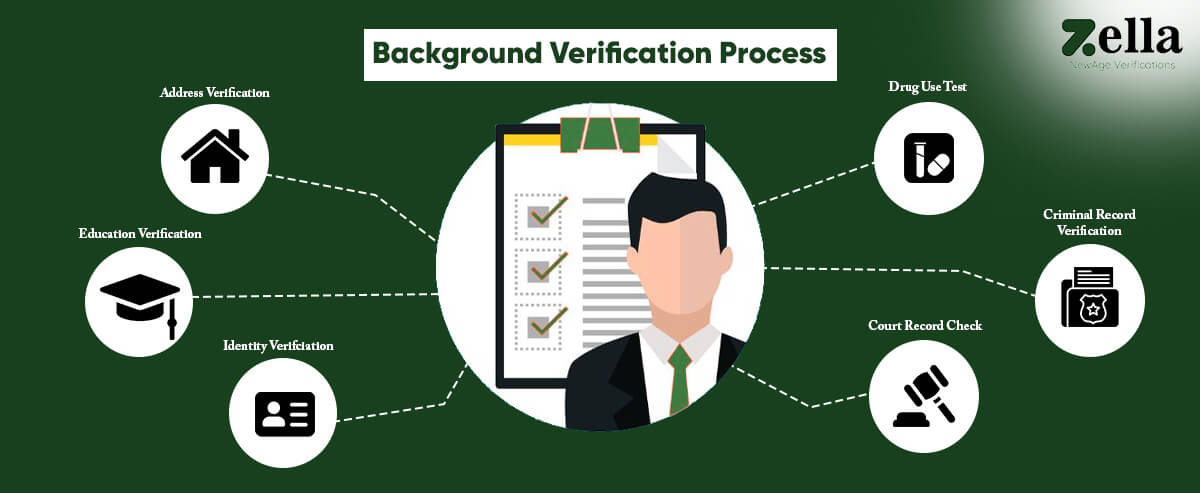

BGV may include identity checks, address verification, education and employment validation, criminal or civil case screening, credit or financial behavior review, and scanning public news or online footprints. Traditionally, this process was manual and time-consuming, but today it is increasingly automated using AI, search APIs, and data analysis to reduce errors and false matches (for example, people with the same name).

# **Why Do We Need Background Verification?**
Background verification is essential for risk management and trust. It helps organizations:

* avoid hiring or partnering with high-risk individuals

* reduce fraud, legal exposure, and reputational damage

* ensure workplace safety and compliance

* make informed, evidence-based decisions

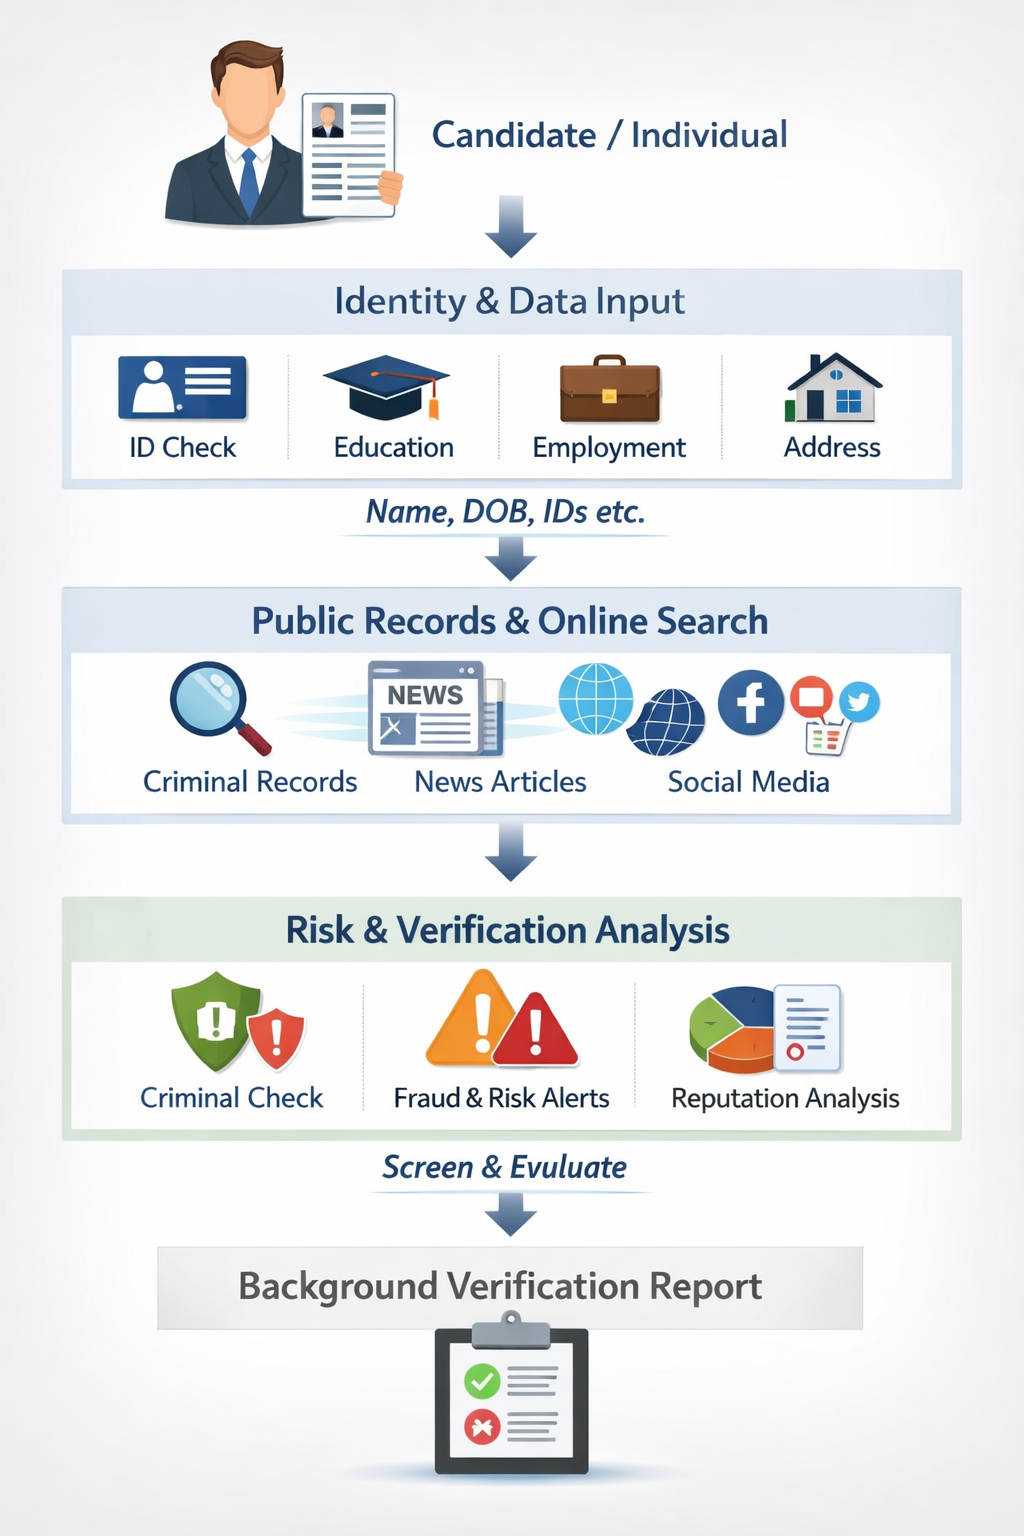

#**What is CrewAI**

The Crew framework is an organized, interactive model designed for collaborative work among AI agents.

### 1. Crew
- **What is it?**
  - A structured system encompassing agents, processes, tasks, and outcomes.
  - Think of it as the environment or ecosystem in which all other parts operate.

### 2. AI Agents
- **Role:**
  - "Intelligent" entities capable of collaboration and decision-making.
  - They can delegate tasks, ask questions, and interact dynamically.
- **Interaction:**
  - Agents communicate with each other to manage workload effectively.
  - They utilize tools to enhance their performance.

### 3. Tools
- **Purpose:**
  - External resources or utilities used by AI agents.
  - Provide support for completing tasks efficiently and effectively.

### 4. Process
- **Function:**
  - Defines and organizes how agents collaborate and assign tasks.
  - Manages how agents interact and execute their work.
- **Interactions:**
  - Receives input or guidance from agents.
  - Provides feedback loops back to agents for continuous improvement.
  - Ensures tasks are systematically allocated.

### 5. Tasks
- **Definition:**
  - Specific units of work to be executed within the Crew framework.
  - Clearly defined steps or jobs created and distributed by the process.
- **Characteristics:**
  - Can specify or override particular tools required for completion.
  - May assign certain tasks explicitly to specific AI agents.



### Workflow Summary:
- **Step-by-step:**
  1. **AI Agents** collaborate, communicate, and delegate tasks among themselves.
  2. **Process** organizes these interactions, determining how tasks are managed.
  3. **Tasks** are assigned clearly, possibly with specific tools or agents required.
  4. **Tasks** are completed by agents using available **Tools**.
  5. **Outcomes** are produced, demonstrating successful execution and fulfillment of objectives.





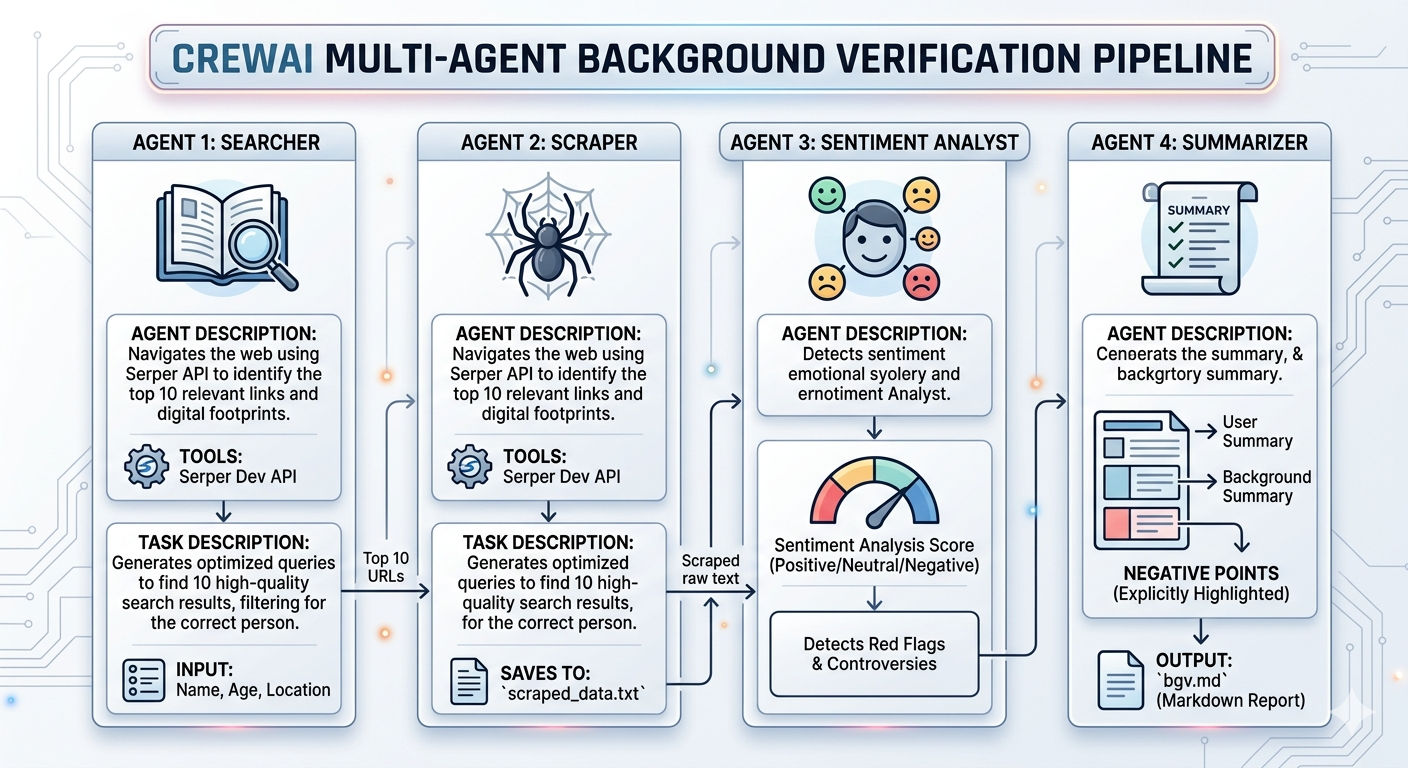

In [1]:
!pip install crewai crewai[tools] langchain-google-genai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.6/68.6 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 kB 1.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.1/68.1 kB 5.7 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of opentelemetry-exporter-otlp-proto-grpc to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of typer to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 886.2/886.2 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 766.5/766.5 kB 42.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# **Setting up the API keys and Model**

In [3]:
import os
from google.colab import userdata
from crewai import Agent, Task, Crew, Process, LLM
from crewai_tools import SerperDevTool, ScrapeWebsiteTool

# Setting up environment variables from Colab Secrets
os.environ["SERPER_API_KEY"] = userdata.get('SERPER_API_KEY')
gemini_api_key = userdata.get('GOOGLE_API_KEY')

# Initialize Gemini LLM
gemini_llm = LLM(
    model="gemini/gemini-2.5-flash",
    api_key=gemini_api_key,
    temperature=0.2
)

# **SEARCHER: Finds the links**
Navigates the web using Serper API to identify the top 10 relevant links and digital footprints for the specified individual

In [4]:
searcher = Agent(
    role='Search Specialist',
    goal='Generate search queries and find the top 10 most relevant links for {name}, age {age}, in {location}.',
    backstory='Expert at finding digital footprints and public records using advanced search operators.',
    tools=[SerperDevTool()],
    llm=gemini_llm,
    verbose=True
)

#**SCRAPER: Extracts the text**
Extracts comprehensive text data from identified URLs using ScrapeWebsiteTool, ensuring all public information is captured for deep analysis.

In [5]:
scraper = Agent(
    role='Data Extraction Expert',
    goal='Scrape the full text content from the URLs provided by the Searcher.',
    backstory='Skilled at navigating websites and extracting clean, relevant text for analysis.',
    tools=[ScrapeWebsiteTool()],
    llm=gemini_llm,
    verbose=True
)

#**SENTIMENT ANALYST: Checks the "vibe" (intent)**
Evaluates the emotional tone of scraped content to detect red flags, controversies, or negative patterns in the person's history.

In [6]:
analyst = Agent(
    role='Sentiment & Risk Analyst',
    goal='Analyze the tone and sentiment of the scraped content to identify any negative or controversial themes.',
    backstory='A specialist in behavior analysis and public sentiment detection.',
    llm=gemini_llm,
    verbose=True
)

#**SUMMARIZER: Final Report Builder**
Synthesizes raw data into a professional report, highlighting key achievements, values, and explicitly listing any identified negative points clearly.

In [7]:
summarizer = Agent(
    role='Executive Reporter',
    goal='Compile all findings into a structured User Summary and a 10-article Combined Background Summary.',
    backstory='Professional editor who can distill massive amounts of data into concise, actionable insights.',
    llm=gemini_llm,
    verbose=True
)

# **Search Task**
Generates optimized queries to find 10 high-quality search results, filtering for the correct person based on age and location.

In [8]:
search_task = Task(
    description='Search for {name}, age {age}, living in {location}. Identify the top 10 URLs related to them.',
    expected_output='A list of 10 relevant URLs and short descriptions.',
    agent=searcher
)

# **Scrape Task**
Systematically visits each URL to retrieve full text content, saving the raw data into a local file for processing.

In [9]:
scrape_task = Task(
    description='Visit the URLs provided in the search task and extract the full text body of the articles.',
    expected_output='A large raw text dataset containing all information from the 10 websites.',
    agent=scraper,
    context=[search_task]
)

# **Sentiment Task**
Processes the extracted text to identify reputational risks and categorize findings into positive, neutral, or negative sentiment clusters.

In [10]:
sentiment_task = Task(
    description='Perform sentiment analysis on the scraped text. Identify if the mentions are positive, neutral, or negative.',
    expected_output='A detailed breakdown of sentiment scores and highlighted negative phrases.',
    agent=analyst,
    context=[scrape_task]
)

# **Summary Task**
Compiles all findings into a final Markdown report, providing a detailed user profile and a structured background verification summary.

In [11]:
summary_task = Task(
    description="""Create a two-part report:
    1. User Summary: A personal profile (values, achievements).
    2. Background Summary: A summary of the 10 articles.
    3. NEGATIVE POINTS: A dedicated section for any red flags or negative findings about the user only. Be specific. Don't make generic statements.""",
    expected_output='A final Markdown report with "User Summary",  and "Background Summary", and "Negative Points" sections.',
    agent=summarizer,
    context=[scrape_task, sentiment_task]
)

# **Assemble the team for the Kickoff**

In [ ]:
bgv_crew = Crew(
    agents=[searcher, scraper, analyst, summarizer],
    tasks=[search_task, scrape_task, sentiment_task, summary_task],
    process=Process.sequential,
    verbose=True
)

# User Inputs
user_inputs = {
    'name': 'Sampurn Rattan',
    'age': '34',
    'location': 'India'
}

# Run the project
result = bgv_crew.kickoff(inputs=user_inputs)

# Output the result
from IPython.display import Markdown
Markdown(str(result))

In [ ]:
# Save the result to a markdown file
with open('bgv.md', 'w', encoding='utf-8') as f:
    f.write(str(result))

print("Success: Report saved as bgv.md")

# **What's next ?**
How will you tackle the Hallucinations ??